# Which admission coordinate is worth its machinery?

`inventory_impact_value_ceiling.ipynb` established that most PLP capital comes from *where* flow lands, not how much of it there is, and that refusing concentrating flow captures much of that without assuming anything about trader behavior. It did not say which statistic the protocol should compute. This notebook answers that, and it answers it for a cap rather than a fee.

## Two assumptions fixed in advance

- **A refused trader does not trade.** No relocation, no substitution to a neighbouring range. Refusal forgoes that trade's income permanently. This is the conservative reading and it removes elasticity from the cap results entirely.
- **A fee's job is compensation, not deterrence.** The fee must leave PLPs whole when the trader piles on anyway. Nothing below depends on a trader changing behaviour in response to price.

## The ladder

Every rule is a **level cap on the resulting whole book** — "after this mint, statistic `S` must not exceed `θ`" — because a level cap cannot be defeated by splitting one order into many, while a threshold on the per-trade increment can be.

The candidates differ along three axes: centering (subtract expected payout, or not), tail shape (average the worst five buckets, or take the single worst point), and region definition (probability mass, or price width).

| Rung | Statistic | On-chain state required |
| --- | --- | --- |
| **A** `K95_grid` | `mean(top 5 bucket maxima) − E[payout]` | 100-bucket grid, top-five scan, `E_frozen`, verified probability snapshot |
| **B** uncentered tail | `mean(top 5 bucket maxima)` | grid and top-five scan; no `E_frozen` |
| **C** `L − E` | `max(payout) − E[payout]` | **two scalars**: existing payout liability, plus a running expected-payout sum |
| **D** `L` | `max(payout)` | nothing new — this is the shipped payout-liability cap |
| **E** price regions | `max over 100 equal-price-width regions of mean payout` | region sums only; **no probabilities anywhere**, so nothing can go stale |

Rung D is the null hypothesis. It is worth taking seriously: `L` already rises roughly dollar-for-dollar on a same-range pile-on, so it is not blind to concentration. Its known defect is that it also penalizes a book that is *fully funded* — uniform coverage has zero risk but maximal `L` — so an `L` cap should waste refusals on harmless trades. Rung C tests whether subtracting expected payout fixes exactly that, using two scalars instead of a grid.

Rung E is the only rung immune to snapshot staleness, because it never asks what anything's probability is.

## Fair comparison

Each rung's `θ` has different units, so comparing them at some arbitrary setting would be meaningless. Instead **every rung is tuned by bisection to refuse the same amount of volume**, and then judged on how much true economic capital it removed for that identical cost. Equal cost, compare benefit.

The objective stays the honest one from the previous notebook: true `K` over 2,000 equal-probability settlement cells, never the estimator being tested. A rung is graded on what it achieves, not on the quantity it happens to control.

In [1]:
"""Part 1 — primitives, the five candidate statistics, and their self-checks."""

from __future__ import annotations

from dataclasses import dataclass
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CELLS = 2_000
TAIL_CELLS = CELLS // 20
BUCKET_CELLS = 20           # 100 buckets of 1% probability mass, as the design specifies
BUCKETS = CELLS // BUCKET_CELLS
TOP_BUCKETS = 5
REGIONS = 100               # equal-price-width regions for rung E
TOTAL_VOL = 0.02            # price dispersion used only to place rung E's price regions

BASE_FEE_RATE = 0.02
FEE_RAMP = 1.0


@dataclass(frozen=True)
class Trade:
    lower: int
    upper: int
    quantity: float

    @property
    def mass(self) -> float:
        return (self.upper - self.lower) / CELLS

    @property
    def fee(self) -> float:
        m = self.mass
        return BASE_FEE_RATE * float(np.sqrt(m * (1.0 - m))) * FEE_RAMP * self.quantity


def true_capital(payout: np.ndarray) -> float:
    """The objective: centered 95% expected shortfall at cell resolution."""
    cut = CELLS - TAIL_CELLS
    return float(np.partition(payout, cut)[cut:].mean() - payout.mean())


# --- The five candidate admission statistics ----------------------------------
# Each maps a resulting payout book to one number that a level cap bounds.

def _bucket_maxima(payout: np.ndarray) -> np.ndarray:
    return payout.reshape(BUCKETS, BUCKET_CELLS).max(axis=1)


def _tail_bucket_mean(payout: np.ndarray) -> float:
    maxima = _bucket_maxima(payout)
    cut = BUCKETS - TOP_BUCKETS
    return float(np.partition(maxima, cut)[cut:].mean())


def stat_k95_grid(payout: np.ndarray) -> float:
    return _tail_bucket_mean(payout) - float(payout.mean())


def stat_tail_uncentered(payout: np.ndarray) -> float:
    return _tail_bucket_mean(payout)


def stat_l_minus_e(payout: np.ndarray) -> float:
    return float(payout.max() - payout.mean())


def stat_l(payout: np.ndarray) -> float:
    return float(payout.max())


# Equal-price-width regions. Cells are equally likely, so they are dense in
# price near the middle and sparse in the wings; spanning the full cell range
# would leave interior regions with no cells at all. The grid therefore covers
# the central 98% of probability and the outer cells fall into the end regions.
_quantiles = (np.arange(CELLS) + 0.5) / CELLS
_normal = NormalDist()
_prices = np.exp(TOTAL_VOL * np.array([_normal.inv_cdf(q) for q in _quantiles]))
_region_edges = np.linspace(_prices[CELLS // 100], _prices[-CELLS // 100 - 1], REGIONS + 1)
REGION_OF_CELL = np.clip(np.searchsorted(_region_edges, _prices, side="right") - 1,
                         0, REGIONS - 1)
REGION_CELL_COUNT = np.bincount(REGION_OF_CELL, minlength=REGIONS).astype(float)
assert REGION_CELL_COUNT.min() > 0, "an empty price region would make the statistic undefined"


def stat_price_region(payout: np.ndarray) -> float:
    """Worst mean payout across equal-price-width regions.

    Region *maxima* would collapse to `max(payout)` and duplicate rung D, so the
    region measure is a mean. This is the only rung that never consults a
    probability, and therefore the only one nothing can make stale. For small
    total volatility `exp(vol*z)` is nearly linear in `z`, so equal price widths
    are close to equal tick widths and the rung barely depends on `TOTAL_VOL`.
    """
    sums = np.bincount(REGION_OF_CELL, weights=payout, minlength=REGIONS)
    return float((sums / REGION_CELL_COUNT).max())


LADDER = {
    "A  K95_grid": stat_k95_grid,
    "B  tail, uncentered": stat_tail_uncentered,
    "C  L - E": stat_l_minus_e,
    "D  L (shipped)": stat_l,
    "E  price regions": stat_price_region,
}


def payout_profile(trades) -> np.ndarray:
    edges = np.zeros(CELLS + 1)
    for trade in trades:
        edges[trade.lower] += trade.quantity
        edges[trade.upper] -= trade.quantity
    return np.cumsum(edges[:-1])


# --- Self-checks --------------------------------------------------------------
# Parity with frozen_grid_inventory_impact.ipynb on the objective, then the
# behaviour that separates the rungs: a fully funded book carries zero risk.
_full = payout_profile([Trade(0, CELLS, 1_000.0)])
_pile = payout_profile([Trade(0, CELLS // 20, 1_000.0)])
_plateau = payout_profile([Trade(0, CELLS // 10, 900.0)])
assert abs(true_capital(_full)) < 1e-9
assert abs(true_capital(_pile) - 950.0) < 1e-9
assert abs(true_capital(_plateau) - 810.0) < 1e-9

checks = pd.DataFrame([
    {"book": "uniform full coverage, $1,000 (zero risk)",
     "true K": true_capital(_full), **{name: fn(_full) for name, fn in LADDER.items()}},
    {"book": "pile-on, 5% mass, $1,000",
     "true K": true_capital(_pile), **{name: fn(_pile) for name, fn in LADDER.items()}},
])

print(f"{CELLS} cells, {BUCKETS} buckets of {BUCKET_CELLS} cells, "
      f"top {TOP_BUCKETS} buckets in the tail term")
print("Objective parity with the frozen-grid notebook passed on all three reference books.")
print()
print("The separating case: uniform coverage is riskless, so a statistic that scores it")
print("high will refuse harmless trades. Centered rungs A and C read zero; D and B do not.")
display(checks.style.format("${:,.0f}", subset=checks.columns[1:]).hide(axis="index"))

2000 cells, 100 buckets of 20 cells, top 5 buckets in the tail term
Objective parity with the frozen-grid notebook passed on all three reference books.

The separating case: uniform coverage is riskless, so a statistic that scores it
high will refuse harmless trades. Centered rungs A and C read zero; D and B do not.


book,true K,A K95_grid,"B tail, uncentered",C L - E,D L (shipped),E price regions
"uniform full coverage, $1,000 (zero risk)",$0,$0,"$1,000",$0,"$1,000","$1,000"
"pile-on, 5% mass, $1,000",$950,$950,"$1,000",$950,"$1,000","$1,000"


In [2]:
"""Part 2 — flow, the level-cap runner, and equal-volume calibration."""

WIDTH_MASSES = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
THEME_SPREAD_CELLS = 40
MEDIAN_QUANTITY = 1_000.0
QUANTITY_LOG_SD = 0.8
TRADES_PER_MARKET = 200
CENTRAL_CLUSTERING = 0.5
TARGET_VOLUME_KEPT = 0.75
THETA_GRID_POINTS = 48
SEEDS = 12


def draw_flow(n_trades: int, clustering: float, rng: np.random.Generator) -> list[Trade]:
    theme = int(rng.integers(0, CELLS))
    trades = []
    for _ in range(n_trades):
        width = int(round(float(rng.choice(WIDTH_MASSES)) * CELLS))
        if rng.random() < clustering:
            center = int(round(rng.normal(theme, THEME_SPREAD_CELLS)))
        else:
            center = int(rng.integers(0, CELLS))
        lower = int(np.clip(center - width // 2, 0, CELLS - width))
        quantity = float(MEDIAN_QUANTITY * np.exp(rng.normal(0.0, QUANTITY_LOG_SD)))
        trades.append(Trade(lower, lower + width, quantity))
    return trades


def run_cap(trades, stat, theta: float | None) -> dict:
    """Admit trades in arrival order under a level cap on the resulting book.

    A refused trade is lost outright: the trader does not relocate, so its fee
    and volume are forgone. `path_max` is the largest statistic reached, which
    bounds the useful calibration range.
    """
    payout = np.zeros(CELLS)
    income = 0.0
    volume = 0.0
    accepted = 0
    path_max = 0.0

    for trade in trades:
        payout[trade.lower:trade.upper] += trade.quantity
        level = stat(payout)
        if theta is not None and level > theta:
            payout[trade.lower:trade.upper] -= trade.quantity
            continue
        path_max = max(path_max, level)
        income += trade.fee
        volume += trade.quantity
        accepted += 1

    return {"K": true_capital(payout), "income": income, "volume": volume,
            "accepted": accepted, "path_max": path_max}


def calibrate_to_volume(trades, stat, target_volume: float) -> dict:
    """Pick the cap that refuses closest to the target amount of volume.

    A grid search rather than a bisection: accepting an earlier trade changes
    the book and can cause a later refusal that a tighter cap would have
    avoided, so volume kept is not guaranteed monotone in the threshold and
    bisection would not be sound.
    """
    unconstrained = run_cap(trades, stat, None)
    ceiling = unconstrained["path_max"]
    grid = np.geomspace(ceiling * 1e-4, ceiling * 1.001, THETA_GRID_POINTS)
    best = None
    for theta in grid:
        outcome = run_cap(trades, stat, float(theta))
        gap = abs(outcome["volume"] - target_volume)
        if best is None or gap < best[0]:
            best = (gap, float(theta), outcome)
    return {"theta": best[1], **best[2]}


def ladder_on_flow(trades) -> tuple[dict, dict[str, dict]]:
    baseline = run_cap(trades, stat_l, None)
    target = TARGET_VOLUME_KEPT * baseline["volume"]
    return baseline, {
        name: calibrate_to_volume(trades, stat, target) for name, stat in LADDER.items()
    }


records: dict[str, list[dict]] = {}
baselines = []
for seed in range(SEEDS):
    flow = draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, np.random.default_rng(seed))
    baseline, outcomes = ladder_on_flow(flow)
    baselines.append(baseline)
    for name, outcome in outcomes.items():
        records.setdefault(name, []).append(
            {**outcome,
             "capital removed": 1.0 - outcome["K"] / baseline["K"],
             "volume kept": outcome["volume"] / baseline["volume"],
             "income kept": outcome["income"] / baseline["income"],
             "R gain": (outcome["income"] / outcome["K"])
                       / (baseline["income"] / baseline["K"]) - 1.0}
        )

base_frame = pd.DataFrame(baselines)
ladder = pd.DataFrame([
    {"rung": name,
     "volume kept": pd.DataFrame(rows)["volume kept"].mean(),
     "income kept": pd.DataFrame(rows)["income kept"].mean(),
     "capital removed": pd.DataFrame(rows)["capital removed"].mean(),
     "capital removed sd": pd.DataFrame(rows)["capital removed"].std(),
     "R gain": pd.DataFrame(rows)["R gain"].mean()}
    for name, rows in records.items()
])

print(f"{SEEDS} markets, {TRADES_PER_MARKET} trades, clustering {CENTRAL_CLUSTERING}")
print(f"uncapped baseline: K ${base_frame['K'].mean():,.0f}, "
      f"income ${base_frame['income'].mean():,.0f}")
print(f"every rung calibrated to keep ~{TARGET_VOLUME_KEPT:.0%} of volume, "
      f"achieved {ladder['volume kept'].min():.1%} to {ladder['volume kept'].max():.1%}")
print()
best = ladder.loc[ladder["capital removed"].idxmax()]
null = ladder.loc[ladder["rung"] == "D  L (shipped)"].iloc[0]
cheap = ladder.loc[ladder["rung"] == "C  L - E"].iloc[0]
print(f"best rung:            {best['rung']}  removes {best['capital removed']:.1%}")
print(f"two-scalar rung C:    removes {cheap['capital removed']:.1%} "
      f"({cheap['capital removed'] / best['capital removed']:.0%} of the best)")
print(f"shipped L cap (null): removes {null['capital removed']:.1%} "
      f"({null['capital removed'] / best['capital removed']:.0%} of the best)")
display(ladder.style.format({
    "volume kept": "{:.1%}", "income kept": "{:.1%}",
    "capital removed": "{:.1%}", "capital removed sd": "{:.3f}", "R gain": "{:+.1%}",
}).hide(axis="index").set_caption(
    "Capital removed at equal volume cost — higher is better"))

12 markets, 200 trades, clustering 0.5
uncapped baseline: K $61,474, income $1,077
every rung calibrated to keep ~75% of volume, achieved 74.4% to 75.1%

best rung:            D  L (shipped)  removes 62.5%
two-scalar rung C:    removes 60.6% (97% of the best)
shipped L cap (null): removes 62.5% (100% of the best)


rung,volume kept,income kept,capital removed,capital removed sd,R gain
A K95_grid,74.8%,70.0%,62.4%,0.063,+92.7%
"B tail, uncentered",74.6%,71.7%,56.1%,0.066,+66.6%
C L - E,75.1%,71.1%,60.6%,0.054,+84.7%
D L (shipped),74.4%,69.9%,62.5%,0.063,+92.6%
E price regions,75.0%,70.6%,61.3%,0.062,+88.5%


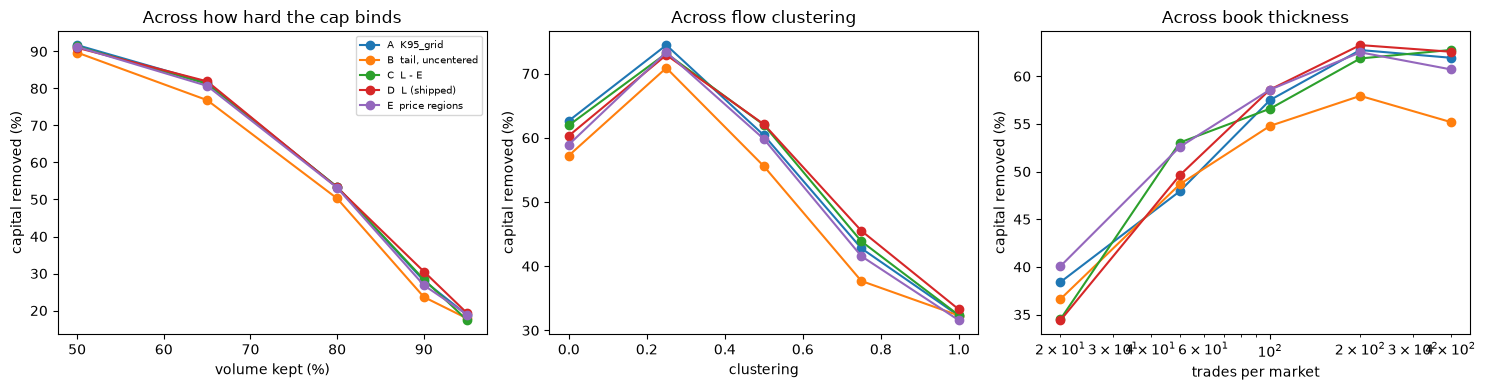

Capital removed by rung, across the volume frontier:
  widest gap between the best and worst rung at any target: 6.9%

Paired contrast, full grid coordinate minus the shipped L cap, on identical
markets. A confidence interval straddling zero means the extra state buys nothing.
  settings where the grid wins or loses by more than two standard errors: 2 of 15
    across volume targets, 0.9: -2.5% (se 1.2%)
    across clustering, 0.75: -2.7% (se 1.3%)


rung,A K95_grid,"B tail, uncentered",C L - E,D L (shipped),E price regions
volume target,,,,,
0.500000,91.7%,89.7%,91.3%,91.0%,91.3%
0.650000,81.6%,76.8%,81.3%,81.9%,80.7%
0.800000,53.3%,50.3%,53.4%,53.2%,53.2%
0.900000,28.1%,23.7%,28.4%,30.5%,26.8%
0.950000,18.8%,17.9%,17.4%,19.3%,18.9%


In [3]:
"""Part 3 — is the ranking an artifact of one volume target, or of one flow?

A single equal-volume point could hide a difference that appears when the cap
binds harder or softer, so the whole frontier is swept. The flow assumptions
that mattered in the value-ceiling notebook are swept as well.
"""

VOLUME_TARGETS = [0.50, 0.65, 0.80, 0.90, 0.95]
CLUSTERING_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
THICKNESS_GRID = [20, 50, 100, 200, 400]
SWEEP_SEEDS = 16


def sweep(flow_factory, rungs=LADDER, target=TARGET_VOLUME_KEPT,
          seeds: int = SWEEP_SEEDS) -> pd.DataFrame:
    """Run every rung on identical flow, keeping seed-level rows.

    Rungs share each market, so differences between them can be tested as
    paired per-seed contrasts, which removes market-to-market variation from
    the comparison entirely.
    """
    rows = []
    for label, make_flow in flow_factory:
        for seed in range(seeds):
            flow = make_flow(seed)
            baseline = run_cap(flow, stat_l, None)
            for name, stat in rungs.items():
                outcome = calibrate_to_volume(flow, stat, target * baseline["volume"])
                rows.append({
                    "setting": label,
                    "rung": name,
                    "seed": seed,
                    "capital removed": 1.0 - outcome["K"] / baseline["K"],
                    "volume kept": outcome["volume"] / baseline["volume"],
                    "R gain": (outcome["income"] / outcome["K"])
                              / (baseline["income"] / baseline["K"]) - 1.0,
                })
    return pd.DataFrame(rows)


def paired_contrast(raw: pd.DataFrame, left: str, right: str,
                    column: str = "capital removed") -> pd.DataFrame:
    """Per-seed `left - right`, with the standard error of that difference."""
    wide = raw.pivot_table(index=["setting", "seed"], columns="rung", values=column)
    delta = (wide[left] - wide[right]).groupby("setting")
    return pd.DataFrame({
        "mean difference": delta.mean(),
        "standard error": delta.std() / np.sqrt(delta.count()),
    })


def central_flow(seed: int) -> list[Trade]:
    return draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING,
                     np.random.default_rng(4_000 + seed))


volume_raw = pd.concat(
    [sweep([(target, central_flow)], target=target) for target in VOLUME_TARGETS],
    ignore_index=True,
)
volume_frontier = volume_raw.groupby(["setting", "rung"], as_index=False).mean(
    numeric_only=True).rename(columns={"setting": "volume target"})

clustering_raw = sweep([
    (c, lambda seed, c=c: draw_flow(TRADES_PER_MARKET, c,
                                    np.random.default_rng(5_000 + seed)))
    for c in CLUSTERING_GRID
])
thickness_raw = sweep([
    (n, lambda seed, n=n: draw_flow(n, CENTRAL_CLUSTERING,
                                    np.random.default_rng(6_000 + seed)))
    for n in THICKNESS_GRID
])
clustering_sweep = clustering_raw.groupby(["setting", "rung"], as_index=False).mean(
    numeric_only=True)
thickness_sweep = thickness_raw.groupby(["setting", "rung"], as_index=False).mean(
    numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in LADDER:
    part = volume_frontier[volume_frontier["rung"] == name]
    axes[0].plot(part["volume target"] * 100, part["capital removed"] * 100,
                 marker="o", label=name)
    part = clustering_sweep[clustering_sweep["rung"] == name]
    axes[1].plot(part["setting"], part["capital removed"] * 100, marker="o", label=name)
    part = thickness_sweep[thickness_sweep["rung"] == name]
    axes[2].plot(part["setting"], part["capital removed"] * 100, marker="o", label=name)

axes[0].set(title="Across how hard the cap binds", xlabel="volume kept (%)",
            ylabel="capital removed (%)")
axes[1].set(title="Across flow clustering", xlabel="clustering",
            ylabel="capital removed (%)")
axes[2].set(title="Across book thickness", xlabel="trades per market",
            ylabel="capital removed (%)", xscale="log")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

spread = volume_frontier.pivot(index="volume target", columns="rung",
                               values="capital removed")
grid_vs_shipped = pd.concat({
    "across volume targets": paired_contrast(volume_raw, "A  K95_grid", "D  L (shipped)"),
    "across clustering": paired_contrast(clustering_raw, "A  K95_grid", "D  L (shipped)"),
    "across thickness": paired_contrast(thickness_raw, "A  K95_grid", "D  L (shipped)"),
})

print("Capital removed by rung, across the volume frontier:")
print(f"  widest gap between the best and worst rung at any target: "
      f"{(spread.max(axis=1) - spread.min(axis=1)).max():.1%}")
print()
print("Paired contrast, full grid coordinate minus the shipped L cap, on identical")
print("markets. A confidence interval straddling zero means the extra state buys nothing.")
significant = grid_vs_shipped[
    grid_vs_shipped["mean difference"].abs() > 2 * grid_vs_shipped["standard error"]]
print(f"  settings where the grid wins or loses by more than two standard errors: "
      f"{len(significant)} of {len(grid_vs_shipped)}")
if len(significant):
    for (axis, setting), row in significant.iterrows():
        print(f"    {axis}, {setting}: {row['mean difference']:+.1%} "
              f"(se {row['standard error']:.1%})")
display(spread.style.format("{:.1%}").set_caption(
    "Capital removed against how much volume the cap keeps"))
display(grid_vs_shipped.style.format("{:+.2%}").set_caption(
    "K95_grid minus the shipped L cap, paired per market"))

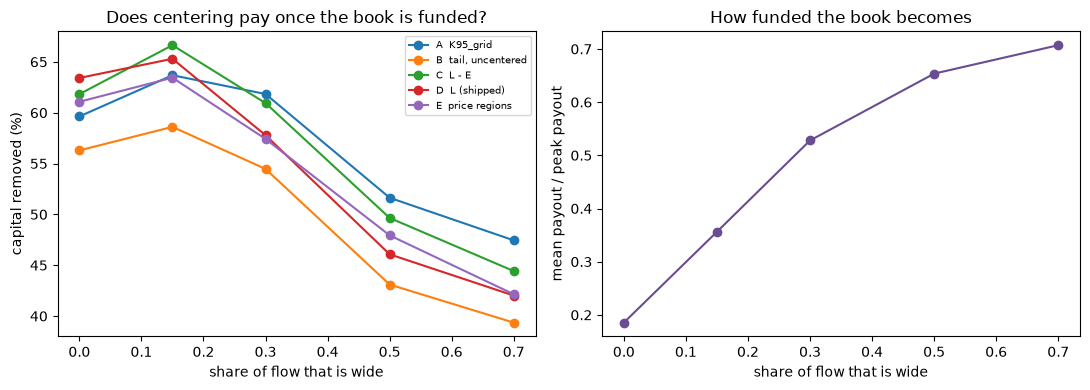

Paired contrasts on identical markets, 24 markets per setting.
Positive means the first coordinate removes more capital at the same volume cost.

  wide   funded          grid - L   two scalars - L  grid - two scalars
  0.00     0.19     -3.8% ± 1.8%     -1.6% ± 2.1%       -2.2% ± 2.0%
  0.15     0.36     -1.6% ± 2.3%     +1.3% ± 1.5%       -3.0% ± 2.2%
  0.30     0.53     +4.1% ± 2.7%     +3.2% ± 3.0%       +0.9% ± 2.0%
  0.50     0.65     +5.6% ± 2.7%     +3.6% ± 2.4%       +2.0% ± 2.1%
  0.70     0.71     +5.4% ± 2.4%     +2.4% ± 2.3%       +3.0% ± 2.0%

Intervals are two standard errors. An interval containing zero means that
comparison is not resolved by this many markets.


rung,A K95_grid,"B tail, uncentered",C L - E,D L (shipped),E price regions
wide fraction,,,,,
0.000000,59.6%,56.3%,61.8%,63.4%,61.1%
0.150000,63.7%,58.6%,66.6%,65.3%,63.4%
0.300000,61.8%,54.5%,60.9%,57.8%,57.4%
0.500000,51.6%,43.1%,49.6%,46.1%,47.9%
0.700000,47.4%,39.4%,44.4%,42.0%,42.1%


In [4]:
"""Part 4 — the regime where `L` is supposed to fail.

`L` scores a fully funded book at its full payout even though such a book
carries no risk, so an `L` cap should waste refusals on harmless trades. The
ordinary flow model never builds a book like that, which is exactly why the
defect may not show up. Here a growing share of flow is deliberately wide, so
the book develops a high funded floor and the defect gets its chance.
"""

WIDE_MASSES = np.array([0.4, 0.6, 0.8])
WIDE_FRACTIONS = [0.0, 0.15, 0.30, 0.50, 0.70]
WIDE_SEEDS = 24  # the contrast that decides the grid's fate, so it gets more markets


def draw_wide_flow(n_trades: int, clustering: float, wide_fraction: float,
                   rng: np.random.Generator) -> list[Trade]:
    theme = int(rng.integers(0, CELLS))
    trades = []
    for _ in range(n_trades):
        wide = rng.random() < wide_fraction
        masses = WIDE_MASSES if wide else WIDTH_MASSES
        width = int(round(float(rng.choice(masses)) * CELLS))
        if not wide and rng.random() < clustering:
            center = int(round(rng.normal(theme, THEME_SPREAD_CELLS)))
        else:
            center = int(rng.integers(0, CELLS))
        lower = int(np.clip(center - width // 2, 0, CELLS - width))
        quantity = float(MEDIAN_QUANTITY * np.exp(rng.normal(0.0, QUANTITY_LOG_SD)))
        trades.append(Trade(lower, lower + width, quantity))
    return trades


wide_raw = sweep([
    (frac, lambda seed, frac=frac: draw_wide_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING,
                                                  frac, np.random.default_rng(7_000 + seed)))
    for frac in WIDE_FRACTIONS
], seeds=WIDE_SEEDS)
wide_sweep = wide_raw.groupby(["setting", "rung"], as_index=False).mean(numeric_only=True)

# How funded does the book actually become? A high floor relative to the peak is
# the condition under which centering matters.
floor_rows = []
for frac in WIDE_FRACTIONS:
    ratios = []
    for seed in range(WIDE_SEEDS):
        flow = draw_wide_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, frac,
                             np.random.default_rng(7_000 + seed))
        profile = payout_profile(flow)
        ratios.append(profile.mean() / profile.max())
    floor_rows.append({"wide fraction": frac, "mean/peak payout": float(np.mean(ratios))})
funding = pd.DataFrame(floor_rows)

wide_pivot = wide_sweep.pivot(index="setting", columns="rung", values="capital removed")
wide_pivot.index.name = "wide fraction"

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for name in LADDER:
    part = wide_sweep[wide_sweep["rung"] == name]
    left.plot(part["setting"], part["capital removed"] * 100, marker="o", label=name)
left.set(title="Does centering pay once the book is funded?",
         xlabel="share of flow that is wide", ylabel="capital removed (%)")
left.legend(fontsize=7)
right.plot(funding["wide fraction"], funding["mean/peak payout"], marker="o",
           color="#6a4c93")
right.set(title="How funded the book becomes",
          xlabel="share of flow that is wide", ylabel="mean payout / peak payout")
plt.tight_layout()
plt.show()

grid_over_l = paired_contrast(wide_raw, "A  K95_grid", "D  L (shipped)")
scalars_over_l = paired_contrast(wide_raw, "C  L - E", "D  L (shipped)")
grid_over_scalars = paired_contrast(wide_raw, "A  K95_grid", "C  L - E")

print(f"Paired contrasts on identical markets, {WIDE_SEEDS} markets per setting.")
print("Positive means the first coordinate removes more capital at the same volume cost.")
print()
print(f"{'wide':>6}  {'funded':>7}  {'grid - L':>16}  {'two scalars - L':>16}  "
      f"{'grid - two scalars':>18}")
for frac in WIDE_FRACTIONS:
    funded = funding.loc[funding['wide fraction'] == frac, 'mean/peak payout'].iloc[0]
    print(f"{frac:>6.2f}  {funded:>7.2f}  "
          f"{grid_over_l.loc[frac, 'mean difference']:>+8.1%} "
          f"±{2 * grid_over_l.loc[frac, 'standard error']:>5.1%}  "
          f"{scalars_over_l.loc[frac, 'mean difference']:>+8.1%} "
          f"±{2 * scalars_over_l.loc[frac, 'standard error']:>5.1%}  "
          f"{grid_over_scalars.loc[frac, 'mean difference']:>+10.1%} "
          f"±{2 * grid_over_scalars.loc[frac, 'standard error']:>5.1%}")
print()
print("Intervals are two standard errors. An interval containing zero means that")
print("comparison is not resolved by this many markets.")
display(wide_pivot.style.format("{:.1%}").set_caption(
    "Capital removed at equal volume cost, as flow widens"))

In [5]:
"""Part 5 — the compensation fee, and whether it is split-resistant.

The fee's job is to leave PLPs whole when the trader piles on anyway. Requiring
`(F+f)/(K+dK) >= F/K` gives `f >= (F/K)*dK`, so the compensating charge is a
flat rate on marginal capital and the rate is a return on capital. No convex
ramp, no scale parameter, no cap, and no refunds: the charge is linear.

Only a coordinate measured in capital units can carry such a rate, so the fee
candidates are rung A and rung C. Uncentered statistics are cap-only.
"""

FEE_RATE = 0.02  # illustrative: intended to add two points of return on capital
FEE_COORDINATES = {"A  K95_grid": stat_k95_grid, "C  L - E": stat_l_minus_e}


def run_fee(trades, stat, rate: float) -> dict:
    """Charge `rate` per dollar of increase in `stat`. Every trade is accepted."""
    payout = np.zeros(CELLS)
    level = 0.0
    base_fees = 0.0
    inventory = 0.0
    for trade in trades:
        payout[trade.lower:trade.upper] += trade.quantity
        after = stat(payout)
        inventory += rate * max(0.0, after - level)
        level = after
        base_fees += trade.fee
    capital = true_capital(payout)
    return {"base fees": base_fees, "inventory fees": inventory, "K": capital,
            "delivered return on capital": inventory / capital,
            "R": (base_fees + inventory) / capital}


def split_every_trade(trades, pieces: int) -> list[Trade]:
    """The same final book, reached in `pieces` times as many mints."""
    out = []
    for trade in trades:
        for _ in range(pieces):
            out.append(Trade(trade.lower, trade.upper, trade.quantity / pieces))
    return out


# Does the charge auto-scale so the delivered return is the configured rate,
# whatever the book looks like? This is the property that makes it behaviour-free.
delivery_rows = []
for clustering in CLUSTERING_GRID:
    for name, stat in FEE_COORDINATES.items():
        delivered, ratios = [], []
        for seed in range(SWEEP_SEEDS):
            flow = draw_flow(TRADES_PER_MARKET, clustering,
                             np.random.default_rng(8_000 + seed))
            outcome = run_fee(flow, stat, FEE_RATE)
            delivered.append(outcome["delivered return on capital"])
            ratios.append(outcome["inventory fees"] / outcome["base fees"])
        delivery_rows.append({
            "clustering": clustering, "coordinate": name,
            "delivered return on capital": float(np.mean(delivered)),
            "charge / base fees": float(np.mean(ratios)),
        })
delivery = pd.DataFrame(delivery_rows)

# Split resistance. A linear charge on marginal capital telescopes, so slicing an
# order cannot reduce it. A threshold on the increment is a different story.
split_flow = draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, np.random.default_rng(11))
split_rows = []
for pieces in (1, 4, 20):
    sliced = split_every_trade(split_flow, pieces)
    linear = run_fee(sliced, stat_k95_grid, FEE_RATE)["inventory fees"]
    # A per-trade increment threshold, set to bite on the unsliced flow.
    unsliced_increments = []
    probe = np.zeros(CELLS)
    previous = 0.0
    for trade in split_flow:
        probe[trade.lower:trade.upper] += trade.quantity
        current = stat_k95_grid(probe)
        unsliced_increments.append(current - previous)
        previous = current
    limit = float(np.percentile([d for d in unsliced_increments if d > 0], 60))
    payout = np.zeros(CELLS)
    level = 0.0
    admitted = 0.0
    for trade in sliced:
        payout[trade.lower:trade.upper] += trade.quantity
        after = stat_k95_grid(payout)
        if after - level > limit:
            payout[trade.lower:trade.upper] -= trade.quantity
            continue
        level = after
        admitted += trade.quantity
    split_rows.append({"slices per order": pieces, "linear charge ($)": linear,
                       "volume admitted past an increment threshold ($)": admitted})
splits = pd.DataFrame(split_rows)

linear_spread = splits["linear charge ($)"].max() / splits["linear charge ($)"].min() - 1.0
threshold_spread = (splits["volume admitted past an increment threshold ($)"].max()
                    / splits["volume admitted past an increment threshold ($)"].min() - 1.0)

low = delivery["delivered return on capital"].min()
high = delivery["delivered return on capital"].max()
print(f"Configured rate {FEE_RATE:.1%} of marginal capital.")
print(f"Delivered return on capital runs {low:.2%} to {high:.2%}, so the charge is a "
      f"conservative")
print(f"floor rather than a dial: it over-collects by {low / FEE_RATE:.1f}x to "
      f"{high / FEE_RATE:.1f}x. Two causes, both")
print("one-directional: refusing rebates makes reversals additive, and both coordinates")
print("overstate true capital by construction. Over-delivery is largest when flow is")
print("diversified, which is when the absolute dollars are smallest.")
print()
print("What the charge costs takers, and the rate implied by a target surcharge:")
for name in FEE_COORDINATES:
    part = delivery[delivery["coordinate"] == name]
    per_unit = (part["charge / base fees"] / FEE_RATE).mean()
    print(f"  {name}: {part['charge / base fees'].min():.2f}x to "
          f"{part['charge / base fees'].max():.2f}x base fees at a {FEE_RATE:.1%} rate; "
          f"a 20% surcharge implies a rate near {0.20 / per_unit:.2%}")
print()
print(f"Split resistance: slicing every order up to 20 ways moves the linear charge by "
      f"{linear_spread:.2%},")
print(f"while the same slicing moves volume admitted past an increment threshold by "
      f"{threshold_spread:+.0%}.")
display(delivery.pivot(index="clustering", columns="coordinate").style.format("{:.3f}")
        .set_caption("A linear charge on marginal capital delivers its rate regardless of flow"))
display(splits.style.format({
    "linear charge ($)": "${:,.2f}",
    "volume admitted past an increment threshold ($)": "${:,.0f}",
}).hide(axis="index").set_caption("Why the cap belongs on the level, not the increment"))

Configured rate 2.0% of marginal capital.
Delivered return on capital runs 2.15% to 4.55%, so the charge is a conservative
floor rather than a dial: it over-collects by 1.1x to 2.3x. Two causes, both
one-directional: refusing rebates makes reversals additive, and both coordinates
overstate true capital by construction. Over-delivery is largest when flow is
diversified, which is when the absolute dollars are smallest.

What the charge costs takers, and the rate implied by a target surcharge:
  A  K95_grid: 0.46x to 2.45x base fees at a 2.0% rate; a 20% surcharge implies a rate near 0.28%
  C  L - E: 0.53x to 2.72x base fees at a 2.0% rate; a 20% surcharge implies a rate near 0.25%

Split resistance: slicing every order up to 20 ways moves the linear charge by 0.42%,
while the same slicing moves volume admitted past an increment threshold by +56%.


slices per order,linear charge ($),volume admitted past an increment threshold ($)
1,"$1,521.26","$172,885"
4,"$1,526.83","$258,399"
20,"$1,527.71","$270,227"


In [6]:
"""Part 6 — verdict."""

def resolved_settings(contrast: pd.DataFrame) -> pd.DataFrame:
    return contrast[contrast["mean difference"].abs() > 2 * contrast["standard error"]]


ordinary = pd.concat([
    paired_contrast(clustering_raw, "A  K95_grid", "D  L (shipped)"),
    paired_contrast(thickness_raw, "A  K95_grid", "D  L (shipped)"),
    paired_contrast(volume_raw, "A  K95_grid", "D  L (shipped)"),
])
ordinary_resolved = resolved_settings(ordinary)
uncentered_loss = (volume_frontier.pivot(index="volume target", columns="rung",
                                         values="capital removed")
                   .pipe(lambda f: f["D  L (shipped)"] - f["B  tail, uncentered"]).mean())

# Where does the funded regime start paying for the extra state?
crossover = [frac for frac in WIDE_FRACTIONS
             if grid_over_l.loc[frac, "mean difference"]
             > 2 * grid_over_l.loc[frac, "standard error"]]

print("WHICH CAP")
print(f"  On ordinary lumpy flow the extra state buys nothing measurable. Across "
      f"{len(ordinary)} settings")
print(f"  of clustering, thickness and cap tightness, the grid separates from the shipped")
print(f"  payout-liability cap in {len(ordinary_resolved)}, and where it does the sign is "
      f"mixed:")
for setting, row in ordinary_resolved.iterrows():
    print(f"    {setting}: {row['mean difference']:+.1%} (two se {2 * row['standard error']:.1%})")
print(f"  The one consistent loser is the uncentered tail statistic, behind L by "
      f"{uncentered_loss:.1%} on average,")
print("  which says centering matters more than tail shape.")
print()
print("  The picture reverses once books become funded. Grid minus L, by wide share:")
for frac in WIDE_FRACTIONS:
    funded = funding.loc[funding['wide fraction'] == frac, 'mean/peak payout'].iloc[0]
    mean = grid_over_l.loc[frac, "mean difference"]
    two_se = 2 * grid_over_l.loc[frac, "standard error"]
    verdict = "grid wins" if mean > two_se else ("L wins" if -mean > two_se else "unresolved")
    print(f"    wide {frac:.2f}, mean payout {funded:.0%} of peak: "
          f"{mean:+.1%} ± {two_se:.1%}  ({verdict})")
if crossover:
    first = min(crossover)
    funded_at = funding.loc[funding['wide fraction'] == first, 'mean/peak payout'].iloc[0]
    print(f"  The crossover is near a wide share of {first:.0%}, where mean payout reaches")
    print(f"  about {funded_at:.0%} of peak.")
print()
print("  Two scalars capture most of that advantage without any grid. Grid minus the")
print("  two-scalar coordinate, by wide share:")
for frac in WIDE_FRACTIONS:
    mean = grid_over_scalars.loc[frac, "mean difference"]
    two_se = 2 * grid_over_scalars.loc[frac, "standard error"]
    print(f"    wide {frac:.2f}: {mean:+.1%} ± {two_se:.1%}"
          f"{'  (resolved)' if abs(mean) > two_se else ''}")
print()
print("WHICH FEE")
print("  A compensating fee is a flat rate on marginal capital and the rate is a return")
print("  on capital, so it needs a coordinate in capital units: the grid, or L minus")
print("  expected payout. It needs no scale, no curvature, no cap, and no refunds.")
print(f"  Linear charges telescope, so slicing an order up to 20 ways moved the total by "
      f"{linear_spread:.2%};")
print(f"  the same slicing let {threshold_spread:+.0%} more volume past an increment "
      f"threshold, which is")
print("  why the cap belongs on the resulting level and not on the per-trade increment.")
print()
print("WHAT WOULD CHANGE THIS")
print("  Every number here rests on generated flow. The result that the grid is")
print("  unnecessary holds only while books stay lumpy; it reverses when a large share of")
print("  flow is wide enough to fund the book. Whether real flow does that is the")
print("  measurement that decides the coordinate, and no amount of simulation settles it.")

WHICH CAP
  On ordinary lumpy flow the extra state buys nothing measurable. Across 15 settings
  of clustering, thickness and cap tightness, the grid separates from the shipped
  payout-liability cap in 2, and where it does the sign is mixed:
    0.75: -2.7% (two se 2.6%)
    0.9: -2.5% (two se 2.4%)
  The one consistent loser is the uncentered tail statistic, behind L by 3.5% on average,
  which says centering matters more than tail shape.

  The picture reverses once books become funded. Grid minus L, by wide share:
    wide 0.00, mean payout 19% of peak: -3.8% ± 1.8%  (L wins)
    wide 0.15, mean payout 36% of peak: -1.6% ± 2.3%  (unresolved)
    wide 0.30, mean payout 53% of peak: +4.1% ± 2.7%  (grid wins)
    wide 0.50, mean payout 65% of peak: +5.6% ± 2.7%  (grid wins)
    wide 0.70, mean payout 71% of peak: +5.4% ± 2.4%  (grid wins)
  The crossover is near a wide share of 30%, where mean payout reaches
  about 53% of peak.

  Two scalars capture most of that advantage without an